<a href="https://colab.research.google.com/github/Tanishqnarayan/AIML/blob/main/AIML_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AIML ASSIGNMENT 10
MULTIMODAL FAKE NEWS DETECTION

Upload your Fakeddit ZIP file if it is not already in Colab.


Saving multimodal_only_samples-20261005T065232Z-1-001.zip to multimodal_only_samples-20261005T065232Z-1-001.zip

Dataset ZIP: multimodal_only_samples-20261005T065232Z-1-001.zip

Dataset extracted.

TSV files found:
 - multimodal_test_public.tsv
 - multimodal_train.tsv
 - multimodal_validate.tsv

Original dataset sizes:
Train     : 564000
Validation: 59342
Test      : 59319

After preprocessing:
Train     : 562466
Validation: 59169
Test      : 59163

Balanced dataset sizes:
Train:
2_way_label
0    300
1    300
Name: count, dtype: int64

Validation:
2_way_label
1    150
0    150
Name: count, dtype: int64

Test:
2_way_label
1    150
0    150
Name: count, dtype: int64

DOWNLOADING IMAGES


  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]


Images successfully downloaded:
Train     : 572
Validation: 286
Test      : 286

TEXT FEATURE EXTRACTION - TF-IDF
TF-IDF feature shape: (572, 383)

IMAGE FEATURE EXTRACTION - RESNET50
Loading pretrained ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
ResNet50 loaded.


  0%|          | 0/572 [00:00<?, ?it/s]

  0%|          | 0/286 [00:00<?, ?it/s]

  0%|          | 0/286 [00:00<?, ?it/s]


Image feature shape:
Train: (572, 2048)
Validation: (286, 2048)
Test: (286, 2048)

MULTIMODAL FEATURE FUSION
Combined feature shape:
Train: (572, 2431)
Validation: (286, 2431)
Test: (286, 2431)

Training Text-only model...
Training Image-only model...
Training Multimodal model...

MODEL PERFORMANCE
     Model  Accuracy  Precision   Recall  F1 Score
 Text Only  0.671329   0.776471 0.468085  0.584071
Image Only  0.730769   0.731884 0.716312  0.724014
Multimodal  0.730769   0.731884 0.716312  0.724014

Label mapping used:
0 = True
1 = False


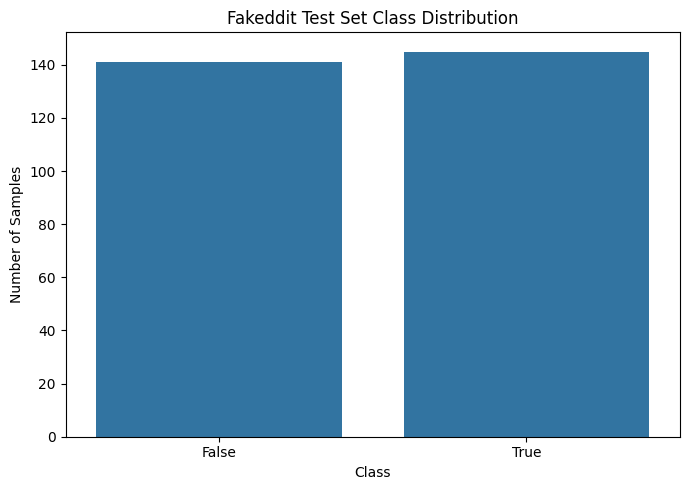

<Figure size 900x600 with 0 Axes>

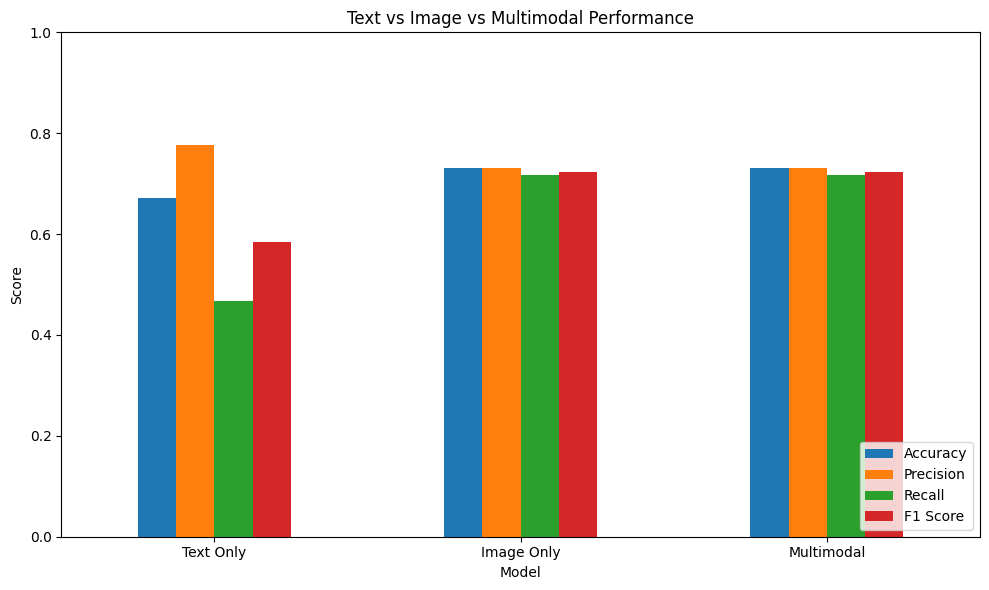

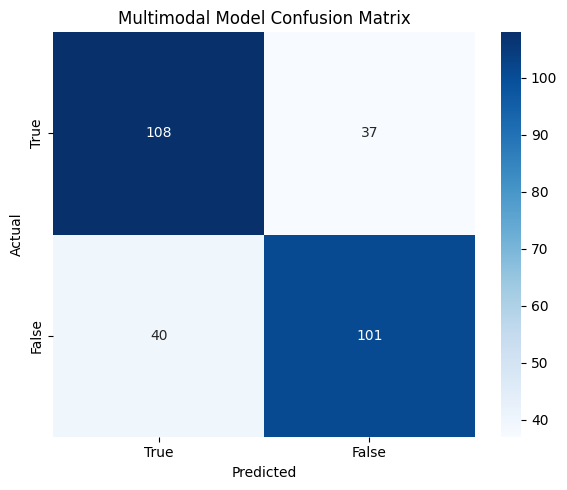

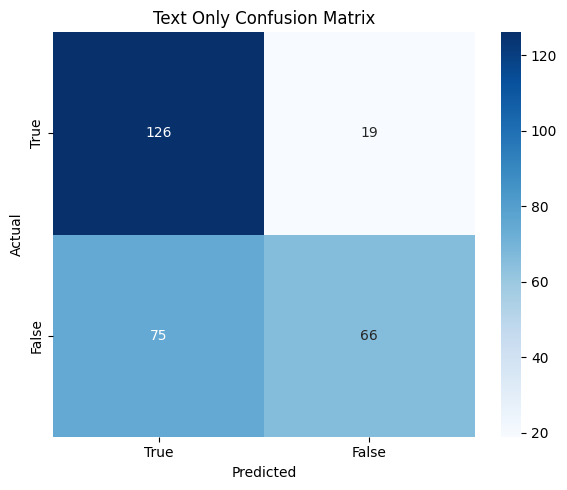

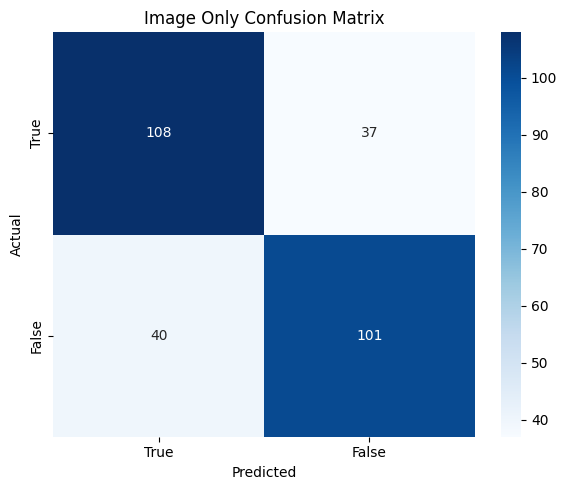

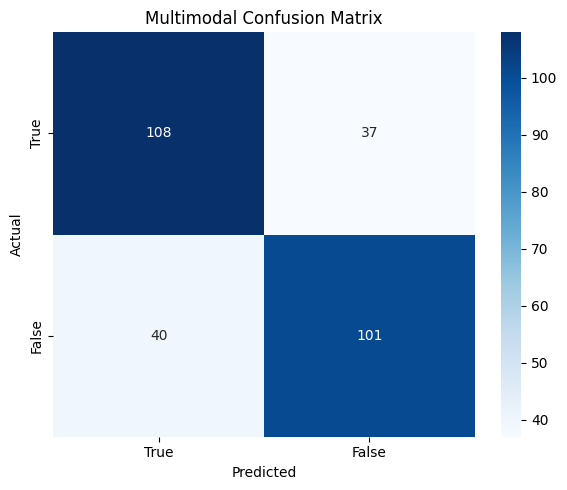


MULTIMODAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

        True       0.73      0.74      0.74       145
       False       0.73      0.72      0.72       141

    accuracy                           0.73       286
   macro avg       0.73      0.73      0.73       286
weighted avg       0.73      0.73      0.73       286


AIML ASSIGNMENT 10
MULTIMODAL FAKE NEWS DETECTION

Dataset:
Fakeddit Multimodal Dataset

Features:
1. Text: clean_title
2. Image: image_url
3. Target: 2_way_label

Text features were extracted using TF-IDF.
Visual features were extracted using pretrained ResNet50.
The text and image features were combined to construct a multimodal
feature representation.

Models evaluated:
1. Text-only Logistic Regression
2. Image-only Logistic Regression
3. Multimodal Logistic Regression

Test samples:
286

Multimodal Accuracy:
0.7308

Multimodal F1 Score:
0.7240

Best model based on accuracy:
Image Only

Best accuracy:
0.7308

The multimodal app

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


ZIP download started.


In [1]:
# ================================================================
# AIML ASSIGNMENT 10
# DESIGN A MODEL TO DETECT FAKE NEWS FROM MULTIMODAL DATA
# Dataset: Fakeddit Multimodal Dataset
# Text  : clean_title
# Image : image_url
# Label : 2_way_label
#
# COMPLETE GOOGLE COLAB - RUN THIS ONE CELL
# ================================================================

!pip -q install pandas numpy scikit-learn matplotlib seaborn pillow requests tqdm scipy

import os
import zipfile
import shutil
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from io import BytesIO
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings("ignore")

print("=" * 70)
print("AIML ASSIGNMENT 10")
print("MULTIMODAL FAKE NEWS DETECTION")
print("=" * 70)

# ================================================================
# 1. CONFIGURATION
# ================================================================

# Number of samples per class.
# Increase to 500/1000 if Colab GPU/RAM is sufficient.
SAMPLES_PER_CLASS = 300

# Image feature size
IMAGE_SIZE = (224, 224)

# Number of TF-IDF features
MAX_TEXT_FEATURES = 3000

# Output directory
OUTPUT_DIR = "/content/Assignment_10_Results"
IMAGE_DIR = os.path.join(OUTPUT_DIR, "downloaded_images")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

# ================================================================
# 2. UPLOAD / FIND DATASET ZIP
# ================================================================

from google.colab import files

print("\nUpload your Fakeddit ZIP file if it is not already in Colab.")

uploaded = files.upload()

zip_files = [f for f in uploaded.keys() if f.lower().endswith(".zip")]

if len(zip_files) == 0:
    raise FileNotFoundError(
        "Please upload the Fakeddit ZIP containing "
        "multimodal_train.tsv, multimodal_validate.tsv and "
        "multimodal_test_public.tsv."
    )

ZIP_FILE = zip_files[0]

print("\nDataset ZIP:", ZIP_FILE)

# ================================================================
# 3. EXTRACT DATASET
# ================================================================

EXTRACT_DIR = "/content/Fakeddit_Data"

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_FILE, "r") as z:
    z.extractall(EXTRACT_DIR)

print("\nDataset extracted.")

# Find TSV files recursively
tsv_files = {}

for root, dirs, fs in os.walk(EXTRACT_DIR):
    for f in fs:
        if f.endswith(".tsv"):
            tsv_files[f] = os.path.join(root, f)

print("\nTSV files found:")

for name, path in tsv_files.items():
    print(" -", name)

required = [
    "multimodal_train.tsv",
    "multimodal_validate.tsv",
    "multimodal_test_public.tsv"
]

for f in required:
    if f not in tsv_files:
        raise FileNotFoundError(f"{f} was not found in the uploaded ZIP.")

# ================================================================
# 4. LOAD DATA
# ================================================================

train_df = pd.read_csv(
    tsv_files["multimodal_train.tsv"],
    sep="\t"
)

valid_df = pd.read_csv(
    tsv_files["multimodal_validate.tsv"],
    sep="\t"
)

test_df = pd.read_csv(
    tsv_files["multimodal_test_public.tsv"],
    sep="\t"
)

print("\nOriginal dataset sizes:")
print("Train     :", len(train_df))
print("Validation:", len(valid_df))
print("Test      :", len(test_df))

# ================================================================
# 5. PREPARE DATA
# ================================================================

def prepare_dataframe(df):

    df = df.copy()

    # Keep only required columns
    df = df[
        [
            "id",
            "clean_title",
            "image_url",
            "hasImage",
            "2_way_label"
        ]
    ]

    # Remove missing values
    df["clean_title"] = df["clean_title"].fillna("")
    df["image_url"] = df["image_url"].fillna("")

    # Keep only samples having text + image
    df = df[
        (df["clean_title"].str.strip() != "") &
        (df["image_url"].str.strip() != "")
    ]

    # Keep binary labels
    df = df[df["2_way_label"].isin([0, 1])]

    # Remove duplicates
    df = df.drop_duplicates(subset=["id"])

    return df.reset_index(drop=True)


train_df = prepare_dataframe(train_df)
valid_df = prepare_dataframe(valid_df)
test_df = prepare_dataframe(test_df)

print("\nAfter preprocessing:")
print("Train     :", len(train_df))
print("Validation:", len(valid_df))
print("Test      :", len(test_df))

# ================================================================
# 6. BALANCED SAMPLING
# ================================================================

def balanced_sample(df, n_per_class):

    samples = []

    for label in sorted(df["2_way_label"].unique()):

        class_df = df[df["2_way_label"] == label]

        n = min(n_per_class, len(class_df))

        samples.append(
            class_df.sample(
                n=n,
                random_state=42
            )
        )

    result = pd.concat(samples)

    return result.sample(
        frac=1,
        random_state=42
    ).reset_index(drop=True)


train_df = balanced_sample(
    train_df,
    SAMPLES_PER_CLASS
)

valid_df = balanced_sample(
    valid_df,
    max(100, SAMPLES_PER_CLASS // 2)
)

test_df = balanced_sample(
    test_df,
    max(100, SAMPLES_PER_CLASS // 2)
)

print("\nBalanced dataset sizes:")
print("Train:")
print(train_df["2_way_label"].value_counts())

print("\nValidation:")
print(valid_df["2_way_label"].value_counts())

print("\nTest:")
print(test_df["2_way_label"].value_counts())

# ================================================================
# 7. DOWNLOAD IMAGES
# ================================================================

print("\n" + "=" * 70)
print("DOWNLOADING IMAGES")
print("=" * 70)

session = requests.Session()

headers = {
    "User-Agent": "Mozilla/5.0"
}

def download_image(row):

    image_id = str(row["id"])
    url = str(row["image_url"])

    path = os.path.join(
        IMAGE_DIR,
        image_id + ".jpg"
    )

    # Already downloaded
    if os.path.exists(path):
        return path

    try:

        response = session.get(
            url,
            headers=headers,
            timeout=10
        )

        if response.status_code != 200:
            return None

        image = Image.open(
            BytesIO(response.content)
        ).convert("RGB")

        image.save(
            path,
            format="JPEG"
        )

        return path

    except Exception:
        return None


def download_dataframe_images(df):

    paths = []

    for _, row in tqdm(
        df.iterrows(),
        total=len(df)
    ):

        paths.append(
            download_image(row)
        )

    df = df.copy()

    df["image_path"] = paths

    df = df.dropna(
        subset=["image_path"]
    ).reset_index(drop=True)

    return df


train_df = download_dataframe_images(train_df)
valid_df = download_dataframe_images(valid_df)
test_df = download_dataframe_images(test_df)

print("\nImages successfully downloaded:")
print("Train     :", len(train_df))
print("Validation:", len(valid_df))
print("Test      :", len(test_df))

if len(train_df) < 20:
    raise RuntimeError(
        "Too few images could be downloaded. "
        "Many old Fakeddit URLs are no longer active."
    )

# ================================================================
# 8. SAVE DOWNLOADED DATA INFORMATION
# ================================================================

train_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "train_multimodal.csv"
    ),
    index=False
)

valid_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "validation_multimodal.csv"
    ),
    index=False
)

test_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "test_multimodal.csv"
    ),
    index=False
)

# ================================================================
# 9. TEXT FEATURE EXTRACTION
# ================================================================

print("\n" + "=" * 70)
print("TEXT FEATURE EXTRACTION - TF-IDF")
print("=" * 70)

X_train_text = train_df["clean_title"]
X_valid_text = valid_df["clean_title"]
X_test_text = test_df["clean_title"]

y_train = train_df["2_way_label"].astype(int)
y_valid = valid_df["2_way_label"].astype(int)
y_test = test_df["2_way_label"].astype(int)

tfidf = TfidfVectorizer(
    max_features=MAX_TEXT_FEATURES,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train_text)

X_valid_tfidf = tfidf.transform(
    X_valid_text
)

X_test_tfidf = tfidf.transform(
    X_test_text
)

print(
    "TF-IDF feature shape:",
    X_train_tfidf.shape
)

# ================================================================
# 10. IMAGE FEATURE EXTRACTION
# ================================================================

print("\n" + "=" * 70)
print("IMAGE FEATURE EXTRACTION - RESNET50")
print("=" * 70)

import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image

print("Loading pretrained ResNet50...")

resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

print("ResNet50 loaded.")

def extract_image_features(df):

    features = []
    valid_indices = []

    for idx, row in tqdm(
        df.iterrows(),
        total=len(df)
    ):

        try:

            img = image.load_img(
                row["image_path"],
                target_size=IMAGE_SIZE
            )

            img_array = image.img_to_array(img)

            img_array = np.expand_dims(
                img_array,
                axis=0
            )

            img_array = preprocess_input(
                img_array
            )

            feature = resnet.predict(
                img_array,
                verbose=0
            )[0]

            features.append(feature)

            valid_indices.append(idx)

        except Exception:
            pass

    return (
        np.array(features),
        valid_indices
    )


X_train_img, train_indices = extract_image_features(
    train_df
)

X_valid_img, valid_indices = extract_image_features(
    valid_df
)

X_test_img, test_indices = extract_image_features(
    test_df
)

# Keep corresponding labels/text
train_df = train_df.iloc[train_indices].reset_index(drop=True)
valid_df = valid_df.iloc[valid_indices].reset_index(drop=True)
test_df = test_df.iloc[test_indices].reset_index(drop=True)

y_train = train_df["2_way_label"].astype(int)
y_valid = valid_df["2_way_label"].astype(int)
y_test = test_df["2_way_label"].astype(int)

# Recalculate TF-IDF after image filtering
X_train_tfidf = tfidf.fit_transform(
    train_df["clean_title"]
)

X_valid_tfidf = tfidf.transform(
    valid_df["clean_title"]
)

X_test_tfidf = tfidf.transform(
    test_df["clean_title"]
)

print("\nImage feature shape:")
print("Train:", X_train_img.shape)
print("Validation:", X_valid_img.shape)
print("Test:", X_test_img.shape)

# ================================================================
# 11. SCALE IMAGE FEATURES
# ================================================================

image_scaler = StandardScaler()

X_train_img_scaled = image_scaler.fit_transform(
    X_train_img
)

X_valid_img_scaled = image_scaler.transform(
    X_valid_img
)

X_test_img_scaled = image_scaler.transform(
    X_test_img
)

# Convert to sparse
X_train_img_sparse = csr_matrix(
    X_train_img_scaled
)

X_valid_img_sparse = csr_matrix(
    X_valid_img_scaled
)

X_test_img_sparse = csr_matrix(
    X_test_img_scaled
)

# ================================================================
# 12. MULTIMODAL FEATURE FUSION
# ================================================================

print("\n" + "=" * 70)
print("MULTIMODAL FEATURE FUSION")
print("=" * 70)

X_train_multi = hstack(
    [
        X_train_tfidf,
        X_train_img_sparse
    ]
).tocsr()

X_valid_multi = hstack(
    [
        X_valid_tfidf,
        X_valid_img_sparse
    ]
).tocsr()

X_test_multi = hstack(
    [
        X_test_tfidf,
        X_test_img_sparse
    ]
).tocsr()

print("Combined feature shape:")
print("Train:", X_train_multi.shape)
print("Validation:", X_valid_multi.shape)
print("Test:", X_test_multi.shape)

# ================================================================
# 13. TRAIN TEXT-ONLY MODEL
# ================================================================

print("\nTraining Text-only model...")

text_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

text_model.fit(
    X_train_tfidf,
    y_train
)

text_pred = text_model.predict(
    X_test_tfidf
)

# ================================================================
# 14. TRAIN IMAGE-ONLY MODEL
# ================================================================

print("Training Image-only model...")

image_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

image_model.fit(
    X_train_img_sparse,
    y_train
)

image_pred = image_model.predict(
    X_test_img_sparse
)

# ================================================================
# 15. TRAIN MULTIMODAL MODEL
# ================================================================

print("Training Multimodal model...")

multimodal_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

multimodal_model.fit(
    X_train_multi,
    y_train
)

multi_pred = multimodal_model.predict(
    X_test_multi
)

# ================================================================
# 16. EVALUATION FUNCTION
# ================================================================

def evaluate_model(
    name,
    y_true,
    y_pred
):

    return {
        "Model": name,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }


results = pd.DataFrame(
    [
        evaluate_model(
            "Text Only",
            y_test,
            text_pred
        ),

        evaluate_model(
            "Image Only",
            y_test,
            image_pred
        ),

        evaluate_model(
            "Multimodal",
            y_test,
            multi_pred
        )
    ]
)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(
    results.to_string(
        index=False
    )
)

# ================================================================
# 17. CLASS LABEL INFORMATION
# ================================================================

# Fakeddit 2-way classification:
# 0 = True
# 1 = False

label_names = {
    0: "True",
    1: "False"
}

print("\nLabel mapping used:")
print("0 = True")
print("1 = False")

# ================================================================
# 18. CLASS DISTRIBUTION GRAPH
# ================================================================

plt.figure(
    figsize=(7,5)
)

sns.countplot(
    x=y_test.map(label_names)
)

plt.title(
    "Fakeddit Test Set Class Distribution"
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.tight_layout()

class_dist_path = os.path.join(
    OUTPUT_DIR,
    "01_class_distribution.png"
)

plt.savefig(
    class_dist_path,
    dpi=200
)

plt.show()

# ================================================================
# 19. MODEL PERFORMANCE GRAPH
# ================================================================

plt.figure(
    figsize=(9,6)
)

results_plot = results.set_index(
    "Model"
)

results_plot[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Text vs Image vs Multimodal Performance"
)

plt.ylabel("Score")
plt.ylim(0,1)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()

performance_path = os.path.join(
    OUTPUT_DIR,
    "02_model_performance_comparison.png"
)

plt.savefig(
    performance_path,
    dpi=200
)

plt.show()

# ================================================================
# 20. MULTIMODAL CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    y_test,
    multi_pred
)

plt.figure(
    figsize=(6,5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["True", "False"],
    yticklabels=["True", "False"]
)

plt.title(
    "Multimodal Model Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

cm_path = os.path.join(
    OUTPUT_DIR,
    "03_multimodal_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=200
)

plt.show()

# ================================================================
# 21. CONFUSION MATRICES FOR ALL MODELS
# ================================================================

predictions = {
    "Text Only": text_pred,
    "Image Only": image_pred,
    "Multimodal": multi_pred
}

for model_name, pred in predictions.items():

    cm = confusion_matrix(
        y_test,
        pred
    )

    plt.figure(
        figsize=(6,5)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["True", "False"],
        yticklabels=["True", "False"]
    )

    plt.title(
        f"{model_name} Confusion Matrix"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()

    safe_name = model_name.lower().replace(
        " ",
        "_"
    )

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"04_{safe_name}_confusion_matrix.png"
        ),
        dpi=200
    )

    plt.show()

# ================================================================
# 22. CLASSIFICATION REPORT
# ================================================================

classification_report_text = classification_report(
    y_test,
    multi_pred,
    target_names=[
        "True",
        "False"
    ],
    zero_division=0
)

print("\n" + "=" * 70)
print("MULTIMODAL CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report_text
)

with open(
    os.path.join(
        OUTPUT_DIR,
        "classification_report.txt"
    ),
    "w"
) as f:

    f.write(
        classification_report_text
    )

# ================================================================
# 23. PREDICTION RESULTS
# ================================================================

prediction_df = test_df[
    [
        "id",
        "clean_title",
        "image_url",
        "2_way_label"
    ]
].copy()

prediction_df["Actual"] = (
    prediction_df["2_way_label"]
    .map(label_names)
)

prediction_df["Predicted"] = (
    pd.Series(multi_pred)
    .map(label_names)
)

prediction_df["Correct"] = (
    prediction_df["Actual"]
    ==
    prediction_df["Predicted"]
)

prediction_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "multimodal_predictions.csv"
    ),
    index=False
)

# ================================================================
# 24. SAVE MODEL RESULTS
# ================================================================

results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "model_performance.csv"
    ),
    index=False
)

# ================================================================
# 25. OBSERVATIONS
# ================================================================

best_model = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

best_accuracy = results["Accuracy"].max()

multi_accuracy = results.loc[
    results["Model"] == "Multimodal",
    "Accuracy"
].iloc[0]

multi_f1 = results.loc[
    results["Model"] == "Multimodal",
    "F1 Score"
].iloc[0]

observation_text = f"""
AIML ASSIGNMENT 10
MULTIMODAL FAKE NEWS DETECTION

Dataset:
Fakeddit Multimodal Dataset

Features:
1. Text: clean_title
2. Image: image_url
3. Target: 2_way_label

Text features were extracted using TF-IDF.
Visual features were extracted using pretrained ResNet50.
The text and image features were combined to construct a multimodal
feature representation.

Models evaluated:
1. Text-only Logistic Regression
2. Image-only Logistic Regression
3. Multimodal Logistic Regression

Test samples:
{len(test_df)}

Multimodal Accuracy:
{multi_accuracy:.4f}

Multimodal F1 Score:
{multi_f1:.4f}

Best model based on accuracy:
{best_model}

Best accuracy:
{best_accuracy:.4f}

The multimodal approach combines information from both the textual
content and associated image instead of relying on only one modality.
"""

with open(
    os.path.join(
        OUTPUT_DIR,
        "observations.txt"
    ),
    "w"
) as f:

    f.write(
        observation_text
    )

print(
    observation_text
)

# ================================================================
# 26. RESULT + CONCLUSION
# ================================================================

result_text = f"""
RESULT

The multimodal fake news detection model was successfully designed
using the Fakeddit dataset. Textual information was represented using
TF-IDF and visual information was represented using pretrained
ResNet50 image features. The two feature sets were combined and
classified using Logistic Regression.

Multimodal Accuracy = {multi_accuracy:.4f}
Multimodal F1 Score = {multi_f1:.4f}

The experiment also compared text-only, image-only and multimodal
models.
"""

conclusion_text = """
CONCLUSION

The experiment demonstrates how multimodal machine learning can be
used for fake news detection by combining textual and visual
information. The comparison between text-only, image-only and
multimodal models shows the usefulness of considering multiple
modalities when analyzing online content. The Fakeddit dataset is
suitable for this task because its multimodal samples contain both
text and corresponding images.
"""

with open(
    os.path.join(
        OUTPUT_DIR,
        "result_and_conclusion.txt"
    ),
    "w"
) as f:

    f.write(
        result_text
    )

    f.write(
        "\n"
    )

    f.write(
        conclusion_text
    )

print(result_text)
print(conclusion_text)

# ================================================================
# 27. CREATE HTML REPORT
# ================================================================

html = f"""
<html>
<head>
<title>AIML Assignment 10 - Multimodal Fake News Detection</title>
<style>
body {{
    font-family: Arial;
    margin: 40px;
}}
table {{
    border-collapse: collapse;
    width: 100%;
}}
th, td {{
    border: 1px solid #999;
    padding: 8px;
    text-align: center;
}}
img {{
    width: 700px;
    max-width: 100%;
}}
</style>
</head>

<body>

<h1>AIML Assignment 10</h1>

<h2>Multimodal Fake News Detection</h2>

<h3>Dataset</h3>
<p>Fakeddit Multimodal Dataset</p>

<h3>Results</h3>

{results.to_html(index=False)}

<h3>Observations</h3>

<pre>{observation_text}</pre>

<h3>Graphs</h3>

<img src="01_class_distribution.png"><br><br>

<img src="02_model_performance_comparison.png"><br><br>

<img src="03_multimodal_confusion_matrix.png"><br><br>

<img src="04_text_only_confusion_matrix.png"><br><br>

<img src="04_image_only_confusion_matrix.png"><br><br>

<img src="04_multimodal_confusion_matrix.png"><br><br>

<h3>Result</h3>

<pre>{result_text}</pre>

<h3>Conclusion</h3>

<pre>{conclusion_text}</pre>

</body>
</html>
"""

html_path = os.path.join(
    OUTPUT_DIR,
    "Assignment_10_Report.html"
)

with open(
    html_path,
    "w"
) as f:

    f.write(html)

# ================================================================
# 28. SAVE DATASET SUMMARY
# ================================================================

summary = pd.DataFrame({
    "Dataset": [
        "Fakeddit"
    ],
    "Train Samples": [
        len(train_df)
    ],
    "Validation Samples": [
        len(valid_df)
    ],
    "Test Samples": [
        len(test_df)
    ],
    "Text Feature Method": [
        "TF-IDF"
    ],
    "Image Feature Method": [
        "ResNet50"
    ],
    "Classifier": [
        "Logistic Regression"
    ],
    "Multimodal Accuracy": [
        multi_accuracy
    ],
    "Multimodal F1": [
        multi_f1
    ]
})

summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "experiment_summary.csv"
    ),
    index=False
)

# ================================================================
# 29. ZIP ALL RESULTS
# ================================================================

ZIP_OUTPUT = "/content/AIML_Assignment_10_Multimodal_Fake_News_Results.zip"

if os.path.exists(ZIP_OUTPUT):
    os.remove(ZIP_OUTPUT)

shutil.make_archive(
    "/content/AIML_Assignment_10_Multimodal_Fake_News_Results",
    "zip",
    OUTPUT_DIR
)

print("\n" + "=" * 70)
print("EXPERIMENT COMPLETED")
print("=" * 70)

print("\nResults folder:")
print(OUTPUT_DIR)

print("\nZIP file:")
print(ZIP_OUTPUT)

# ================================================================
# 30. AUTOMATIC DOWNLOAD
# ================================================================

files.download(
    ZIP_OUTPUT
)

print("\nZIP download started.")